In [1]:
from docling.document_converter import DocumentConverter
from docling.chunking import HybridChunker
from docling_core.transforms.chunker import HierarchicalChunker
from langchain_core.documents import Document
import re

# Chunking and Embeding

## Extraction / Chunking

In [ ]:
## Note :- all manual logic fails and required different logic for different pdf ,current useful method is using
## Docling devolped by the IBM

In [ ]:
## first run the following command for the extraction of the table of content
## pdftotext -f 9 -l 16 -layout ECBC_2024.pdf toc_raw.txt

In [2]:
converter = DocumentConverter()

In [3]:
## Basic PDF Extraction
result = converter.convert("D:\\AiEnergyAssitanceForBuilding\\PdfResourc\\Used\\ECBC_HVAC_TIP_SHEET_2011.pdf")

[INFO] 2026-09-29 19:21:42,077 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-09-29 19:21:42,093 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\prati\AppData\Local\Programs\Python\Python313\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-09-29 19:21:42,093 [RapidOCR] main.py:65: Using C:\Users\prati\AppData\Local\Programs\Python\Python313\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.onnx
[INFO] 2026-09-29 19:21:42,216 [RapidOCR] base.py:22: Using engine_name: onnxruntime
[INFO] 2026-09-29 19:21:42,221 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\prati\AppData\Local\Programs\Python\Python313\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-09-29 19:21:42,222 [RapidOCR] main.py:65: Using C:\Users\prati\AppData\Local\Programs\Python\Python313\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-09-29 19:21:42,284 [RapidOCR] base

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

In [4]:
document = result.document
markdown_output = document.export_to_markdown()
json_output = document.export_to_dict()

In [10]:
print(len(markdown_output))

72869


In [2]:
TARGET_TOKENS = 400
MAX_TOKENS = 600
OVERLAP_TOKENS = 60

## Chunking using langchain

In [11]:
chunker = HybridChunker(max_tokens=500,merge_peers=True)

In [14]:
chunk_iter  = chunker.chunk(dl_doc=result.document)
chunks = list(chunk_iter)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (577 > 512). Running this sequence through the model will result in indexing errors


In [15]:
len(chunks)

60

In [ ]:
chunks[1]

## 1  Structure-Aware Chunking + semantic using docling

                    Docling
                       │
                       ▼
              Structure extraction
                       │
              ┌────────┴────────┐
              │                 │
          Section             Table
              │                 │
              ▼                 ▼
       Paragraph grouping    Table chunk
              │
              ▼
       Size/token check
              │
       ┌──────┴──────┐
       │             │
    Small          Large
       │             │
       ▼             ▼
     Keep       Paragraph/
                sentence split

In [5]:
def structure_aware_chunking(doc):
    """
    Create structure-aware chunks from a DoclingDocument.

    The chunking logic:
    - Keeps headings associated with their content.
    - Preserves document/page metadata where available.
    - Treats tables separately.
    - Creates a new chunk when a new heading/section is encountered.
    """

    chunks = []

    current_heading = []
    current_content = []
    current_page = None

    def save_chunk():
        if not current_content:
            return

        content = "\n".join(current_content).strip()

        if not content:
            return

        metadata = {
            "heading": " > ".join(current_heading),
            "page": current_page,
            "content_type": "text"
        }

        chunks.append(
            Document(
                page_content=content,
                metadata=metadata
            )
        )

    # Iterate through Docling document items
    for item, level in doc.iterate_items():

        item_type = item.__class__.__name__

        # -------------------------
        # Heading
        # -------------------------
        if item_type in ["SectionHeaderItem", "TitleItem"]:

            # Save previous section
            save_chunk()

            current_content.clear()

            text = getattr(item, "text", "").strip()

            if text:
                # Maintain heading hierarchy
                if level is not None:

                    current_heading = current_heading[:level]

                    current_heading.append(text)

                else:
                    current_heading.append(text)

            continue

        # -------------------------
        # Table
        # -------------------------
        if item_type == "TableItem":

            # Save text before table
            save_chunk()
            current_content.clear()

            try:
                table_text = item.export_to_markdown(doc)

            except Exception:
                table_text = str(item)

            chunks.append(
                Document(
                    page_content=table_text,
                    metadata={
                        "heading": " > ".join(current_heading),
                        "page": current_page,
                        "content_type": "table"
                    }
                )
            )

            continue

        # -------------------------
        # Normal text
        # -------------------------
        text = getattr(item, "text", None)

        if text:

            text = text.strip()

            if text:
                current_content.append(text)

        # -------------------------
        # Page information
        # -------------------------
        prov = getattr(item, "prov", None)

        if prov:
            try:
                current_page = prov[0].page_no
            except Exception:
                pass

    # Save final chunk
    save_chunk()

    return chunks


In [6]:
structure_Aware_cunks = structure_aware_chunking(document)

In [8]:
len(structure_Aware_cunks)

61

In [ ]:
for i, chunk in enumerate(structure_Aware_cunks[:5]):

    print("\n" + "=" * 80)
    print(f"CHUNK {i + 1}")

    print("\nMetadata:")
    print(chunk.metadata)

    print("\nContent:")
    print(chunk.page_content[:1000])

## 2 Hierarchial structure

                    PDF
                     │
                     ▼
                  Docling
                     │
        ┌────────────┼────────────┐
        ▼            ▼            ▼
      Text         Tables       Figures
        │            │            │
        └────────────┼────────────┘
                     ▼
             Document hierarchy
                     │
                     ▼
              Parent section
                     │
          ┌──────────┼──────────┐
          ▼          ▼          ▼
       Text       Text        Table
       Child      Child       Child
                              │
                              ▼
                       Preserve rows/
                       columns/header

In [6]:
def get_page_number(item):
    prov = getattr(item, "prov", None)

    if prov:
        try:
            return prov[0].page_no
        except Exception:
            pass

    return None

In [8]:
def create_parent_child_chunks(doc):

    parents = []

    current_parent = None
    current_parent_content = []

    parent_counter = 0
    child_counter = 0

    # -----------------------------------------------------
    # Save current parent
    # -----------------------------------------------------

    def save_parent():

        nonlocal current_parent
        nonlocal current_parent_content

        if current_parent is None:
            return

        current_parent["content"] = current_parent_content.copy()

        parents.append(current_parent)

        current_parent = None
        current_parent_content = []


    # -----------------------------------------------------
    # Iterate through Docling document
    # -----------------------------------------------------

    for item, level in doc.iterate_items():

        item_type = item.__class__.__name__

        page_number = get_page_number(item)

        # =================================================
        # HEADING
        # =================================================

        if item_type in [
            "SectionHeaderItem",
            "TitleItem"
        ]:

            heading_text = getattr(item, "text", "")

            if not heading_text:
                continue

            heading_text = heading_text.strip()

            # New parent section
            save_parent()

            parent_counter += 1

            current_parent = {

                "parent_id": f"parent_{parent_counter}",

                "title": heading_text,

                "level": level,

                "page": page_number,

                "content": []

            }

            continue


        # =================================================
        # TABLE
        # =================================================

        if item_type == "TableItem":

            # If no heading exists yet, create a default parent
            if current_parent is None:

                parent_counter += 1

                current_parent = {

                    "parent_id": f"parent_{parent_counter}",

                    "title": "Document Content",

                    "level": 0,

                    "page": page_number,

                    "content": []

                }

            try:

                table_markdown = item.export_to_markdown(doc)

            except Exception:

                table_markdown = str(item)


            current_parent_content.append({

                "type": "table",

                "content": table_markdown,

                "page": page_number

            })

            continue


        # =================================================
        # TEXT
        # =================================================

        text = getattr(item, "text", None)

        if text:

            text = text.strip()

            if text:

                # If document starts with text before heading
                if current_parent is None:

                    parent_counter += 1

                    current_parent = {

                        "parent_id": f"parent_{parent_counter}",

                        "title": "Document Introduction",

                        "level": 0,

                        "page": page_number,

                        "content": []

                    }


                current_parent_content.append({

                    "type": "text",

                    "content": text,

                    "page": page_number

                })


    # Save final parent
    save_parent()

    # -----------------------------------------------------
    # Create child LangChain Documents
    # -----------------------------------------------------

    child_documents = []

    for parent in parents:

        for element in parent["content"]:

            child_counter += 1

            # =============================================
            # TEXT CHILD
            # =============================================

            if element["type"] == "text":

                child_documents.append(

                    Document(

                        page_content=element["content"],

                        metadata={

                            "chunk_type": "child",

                            "content_type": "text",

                            "child_id": f"child_{child_counter}",

                            "parent_id": parent["parent_id"],

                            "parent_title": parent["title"],

                            "parent_level": parent["level"],

                            "page": element["page"]

                        }

                    )

                )


            # =============================================
            # TABLE CHILD
            # =============================================

            elif element["type"] == "table":

                child_documents.append(

                    Document(

                        page_content=element["content"],

                        metadata={

                            "chunk_type": "child",

                            "content_type": "table",

                            "child_id": f"child_{child_counter}",

                            "parent_id": parent["parent_id"],

                            "parent_title": parent["title"],

                            "parent_level": parent["level"],

                            "page": element["page"]

                        }

                    )

                )


    return parents, child_documents



In [27]:
hirarchial_chunking = create_parent_child_chunks(document)

In [ ]:
hirarchial_chunking

In [17]:
chunker = HierarchicalChunker()
chunks = list(chunker.chunk(document))

In [ ]:
chunks[87]

In [19]:
len(chunks)

221

## 3 Contextual + token aware cbunking
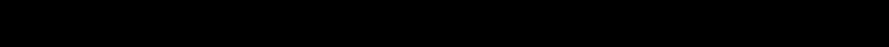
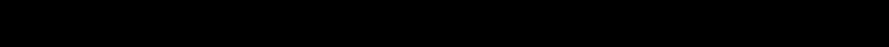

                    PDF
                     │
                     ▼
                  Docling
                     │
          ┌──────────┼──────────┐
          ▼          ▼          ▼
        Text       Tables     Figures
          │          │          │
          ▼          ▼          ▼
      Section      Table      Figure
      hierarchy   hierarchy   metadata
          │
          ▼
     Parent Section
          │
     ┌────┴─────┐
     ▼          ▼
   Text       Table
   Child      Child
     │          │
     ▼          ▼
Token-aware   Table-aware
  split         split
     │          │
     └────┬─────┘
          ▼
   Contextual prefix
          │
          ▼
    Final Documents
          │
          ▼
      Embeddings
          │
          ▼
      Vector DB

In [4]:
def tokenize(text):

    return re.findall(
        r"\w+|[^\w\s]",
        text,
        re.UNICODE
    )
def detokenize(tokens):

    text = " ".join(tokens)

    # Fix spaces before punctuation
    text = re.sub(
        r"\s+([.,!?;:%)\]])",
        r"\1",
        text
    )

    # Fix spaces after opening brackets
    text = re.sub(
        r"([\(\[]) +",
        r"\1",
        text
    )

    return text


In [5]:
def create_context(
    document_name,
    parent_title,
    parent_level,
    page,
    content_type
):

    context_parts = []

    if document_name:
        context_parts.append(
            f"Document: {document_name}"
        )

    if parent_title:
        context_parts.append(
            f"Section: {parent_title}"
        )

    if parent_level is not None:
        context_parts.append(
            f"Section Level: {parent_level}"
        )

    if page is not None:
        context_parts.append(
            f"Page: {page}"
        )

    if content_type:
        context_parts.append(
            f"Content Type: {content_type}"
        )

    return "\n".join(context_parts)

In [7]:
def token_aware_split(
    text,
    target_tokens=TARGET_TOKENS,
    max_tokens=MAX_TOKENS,
    overlap_tokens=OVERLAP_TOKENS
):

    tokens = tokenize(text)

    if len(tokens) <= max_tokens:

        return [text]

    chunks = []

    start = 0

    while start < len(tokens):

        end = min(
            start + target_tokens,
            len(tokens)
        )

        chunk_tokens = tokens[start:end]

        chunk = detokenize(chunk_tokens)

        chunks.append(chunk)

        if end >= len(tokens):
            break

        # Move backward to create overlap
        start = end - overlap_tokens

    return chunks

In [9]:
def contextual_token_aware_chunking(
    doc,
    document_name
):

    chunks = []

    current_parent = None
    current_parent_content = []

    parent_counter = 0
    child_counter = 0

    # --------------------------------------------------------
    # Save current parent
    # --------------------------------------------------------

    def save_parent():

        nonlocal current_parent
        nonlocal current_parent_content

        if current_parent is None:
            return

        current_parent["content"] = (
            current_parent_content.copy()
        )

        process_parent(
            current_parent
        )

        current_parent = None
        current_parent_content = []

    # --------------------------------------------------------
    # Process one parent section
    # --------------------------------------------------------
    def count_tokens(text):

        return len(tokenize(text))
    def process_parent(parent):

        nonlocal child_counter

        for element in parent["content"]:

            content_type = element["type"]

            page = element["page"]

            content = element["content"]

            # ==============================================
            # TEXT
            # ==============================================

            if content_type == "text":

                text_chunks = token_aware_split(
                    content
                )

                for text_chunk in text_chunks:

                    child_counter += 1

                    context = create_context(
                        document_name=document_name,
                        parent_title=parent["title"],
                        parent_level=parent["level"],
                        page=page,
                        content_type="text"
                    )

                    contextual_content = (
                        context
                        + "\n\n"
                        + text_chunk
                    )

                    chunks.append(

                        Document(

                            page_content=contextual_content,

                            metadata={

                                "chunk_type": "child",

                                "content_type": "text",

                                "chunk_id":
                                    f"child_{child_counter}",

                                "parent_id":
                                    parent["parent_id"],

                                "parent_title":
                                    parent["title"],

                                "parent_level":
                                    parent["level"],

                                "page":
                                    page,

                                "document":
                                    document_name,

                                "token_count":
                                    count_tokens(
                                        contextual_content
                                    )

                            }

                        )

                    )

            # ==============================================
            # TABLE
            # ==============================================

            elif content_type == "table":

                child_counter += 1

                context = create_context(
                    document_name=document_name,
                    parent_title=parent["title"],
                    parent_level=parent["level"],
                    page=page,
                    content_type="table"
                )

                contextual_content = (
                    context
                    + "\n\n"
                    + content
                )

                chunks.append(

                    Document(

                        page_content=contextual_content,

                        metadata={

                            "chunk_type": "child",

                            "content_type": "table",

                            "chunk_id":
                                f"child_{child_counter}",

                            "parent_id":
                                parent["parent_id"],

                            "parent_title":
                                parent["title"],

                            "parent_level":
                                parent["level"],

                            "page":
                                page,

                            "document":
                                document_name,

                            "token_count":
                                count_tokens(
                                    contextual_content
                                )

                        }

                    )

                )

    # --------------------------------------------------------
    # Iterate Docling items
    # --------------------------------------------------------

    for item, level in doc.iterate_items():

        item_type = item.__class__.__name__

        page = get_page_number(item)

        # ====================================================
        # HEADING
        # ====================================================

        if item_type in [
            "SectionHeaderItem",
            "TitleItem"
        ]:

            heading = getattr(
                item,
                "text",
                ""
            )

            if not heading:
                continue

            heading = heading.strip()

            save_parent()

            parent_counter += 1

            current_parent = {

                "parent_id":
                    f"parent_{parent_counter}",

                "title":
                    heading,

                "level":
                    level,

                "page":
                    page,

                "content":
                    []

            }

            continue

        # ====================================================
        # TABLE
        # ====================================================

        if item_type == "TableItem":

            if current_parent is None:

                parent_counter += 1

                current_parent = {

                    "parent_id":
                        f"parent_{parent_counter}",

                    "title":
                        "Document Content",

                    "level":
                        0,

                    "page":
                        page,

                    "content":
                        []

                }

            try:

                table_markdown = (
                    item.export_to_markdown(doc)
                )

            except Exception:

                table_markdown = str(item)

            current_parent_content.append({

                "type":
                    "table",

                "content":
                    table_markdown,

                "page":
                    page

            })

            continue

        # ====================================================
        # TEXT
        # ====================================================

        text = getattr(
            item,
            "text",
            None
        )

        if text:

            text = text.strip()

            if text:

                if current_parent is None:

                    parent_counter += 1

                    current_parent = {

                        "parent_id":
                            f"parent_{parent_counter}",

                        "title":
                            "Document Introduction",

                        "level":
                            0,

                        "page":
                            page,

                        "content":
                            []

                    }

                current_parent_content.append({

                    "type":
                        "text",

                    "content":
                        text,

                    "page":
                        page

                })

    # Save final parent
    save_parent()

    return chunks

In [18]:
contexttual_tokenaware_chunks = contextual_token_aware_chunking(
        document,
        document_name="ECBC_HVAC_TIP_SHEET_2011.pdf"
    )

In [19]:
for i, chunk in enumerate(
        contexttual_tokenaware_chunks[:10]
    ):

        print()
        print("=" * 80)

        print(
            f"CHUNK {i + 1}"
        )

        print("-" * 80)

        print(
            "Metadata:"
        )

        print(
            chunk.metadata
        )

        print()

        print(
            "Content:"
        )

        print(
            chunk.page_content[:1500]
        )


CHUNK 1
--------------------------------------------------------------------------------
Metadata:
{'chunk_type': 'child', 'content_type': 'text', 'chunk_id': 'child_1', 'parent_id': 'parent_1', 'parent_title': 'EnErgy COnSErVATIOn BUILDIng CODE TIP SHEET', 'parent_level': 1, 'page': 1, 'document': 'ECBC_HVAC_TIP_SHEET_2011.pdf', 'token_count': 32}

Content:
Document: ECBC_HVAC_TIP_SHEET_2011.pdf
Section: EnErgy COnSErVATIOn BUILDIng CODE TIP SHEET
Section Level: 1
Page: 1
Content Type: text

Version 2.0 - March, 2011

CHUNK 2
--------------------------------------------------------------------------------
Metadata:
{'chunk_type': 'child', 'content_type': 'text', 'chunk_id': 'child_2', 'parent_id': 'parent_2', 'parent_title': 'HVAC SySTEM', 'parent_level': 1, 'page': 1, 'document': 'ECBC_HVAC_TIP_SHEET_2011.pdf', 'token_count': 33}

Content:
Document: ECBC_HVAC_TIP_SHEET_2011.pdf
Section: HVAC SySTEM
Section Level: 1
Page: 1
Content Type: text

Credits: E Source Technology Atlas US DO

## Final structure with embedings

                2000+ PAGE CORPUS
                        │
                     Docling
                        │
             Structure extraction
                        │
        ┌───────────────┼────────────────┐
        ↓               ↓                ↓
   Structure         Semantic       Contextual +
    Chunking         Chunking       Token-aware
        │               │                │
        └───────────────┼────────────────┘
                        ↓
             SAME EMBEDDING MODEL
              BGE-small-en-v1.5
                        │
             ┌──────────┼──────────┐
             ↓          ↓          ↓
          Qdrant      Qdrant     Qdrant
             │          │          │
             └──────────┼──────────┘
                        ↓
                  SAME QUESTIONS
                        ↓
               Embedding Model
                      │
             ┌────────┴────────┐
             ▼                 ▼
         Dense Vector      BM25/Sparse
             │                 │
             └────────┬────────┘
                      ▼
                   Qdrant
                      │
             Hybrid Retrieval
               Dense + BM25
                      │
                      ▼
                   Reranker
                       |
                       |
             Retrieval evaluation
                        ↓
          Recall / Precision / MRR
          Context Precision / Recall
          Latency / Token usage

# Embeding Part

In [9]:
from qdrant_client import QdrantClient
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_qdrant import QdrantVectorStore

In [10]:

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={
        "device": "cuda"
    },
    encode_kwargs={
        "normalize_embeddings": True
    }
)


vector_store = QdrantVectorStore.from_documents(
    documents=structure_Aware_cunks,
    embedding=embeddings,
    path="D:\\M.tech\\Research Area\\RAG pipeline\\DB\\BGE-M3_Embeding\\StructureAwareChunking",
    collection_name="StructureAwareEmbeding",

)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [14]:
client = QdrantClient(path="D:\\M.tech\\Research Area\\RAG pipeline\\DB\\BGE-M3_Embeding\\StructureAwareChunking")

RuntimeError: Storage folder D:\M.tech\Research Area\RAG pipeline\DB\BGE-M3_Embeding\StructureAwareChunking is already accessed by another instance of Qdrant client. If you require concurrent access, use Qdrant server instead.

In [ ]:
# 2. Define the exact same embedding model you used to create the DB
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-m3")

# 3. Use the collection name found in your folder structure
vector_store = QdrantVectorStore(
    client=client,
    collection_name="contextual_token",  # <-- This matches your folder name!
    embedding=embeddings,
)

In [11]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})
docs = retriever.invoke("What is the maximum U-factor for windows?")

In [13]:
docs[0].page_content

"On an annual basis,  continuously  operating air  distribution  fans  can  consume  more electricity  than  chillers  or  boilers,  which run  only  intermittently.  High-efficiency air  distribution  systems  can  substantially reduce  fan  power  required  by  an  HVAC system, resulting in dramatic energy savings.  Because  fan  power  increases  at the square of air speed, delivering a large mass of air at low velocity is a  far  more efficient design strategy than pushing air  through  small  ducts  at  high  velocity. Supplying only as much air as is needed to condition or ventilate a space through the use of variable-air-volume systems is more efficient than supplying a constant volume of air at all times.\nThe  largest  gains  in  efficiency  for air distribution systems are realized in the system design phase during new  construction or major retrofits. Modifications to air distribution systems\nMost of the air in commercial buildings is recirculated  (returned)  through  the 